# Human Mobility in Italy

First we use Lab_Session_5.R file to gain some data insights

In [1]:
library(igraph)
library(ggplot2)
library(RColorBrewer)
library(rgl)
library(geosphere)
library(viridis)
library(patchwork)

source('common.R')


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: viridisLite



In [2]:
# Import the data
dat_nodes <- read.csv("ITA_nodes.csv", header=T, sep=",")
dat_edges <- read.csv("ITA_edges.csv", header=T, sep=",")

dat_nodes$lat <- as.numeric(dat_nodes$lat)
dat_nodes$lon <- as.numeric(dat_nodes$lon)
dat_nodes <- dat_nodes[order(dat_nodes$adm_id),]
rownames(dat_nodes) <- dat_nodes$adm_id

# Get an idea of the orders of magnitude
print(sum(dat_edges$estimated_flow)*1e-6)

# Filter out self-loops and links with zero flow
dat_edges <- dat_edges[which(dat_edges$from!=dat_edges$to & dat_edges$estimated_flow>0),]
print(sum(dat_edges$estimated_flow)*1e-6)

[1] 57.57352
[1] 4.427521


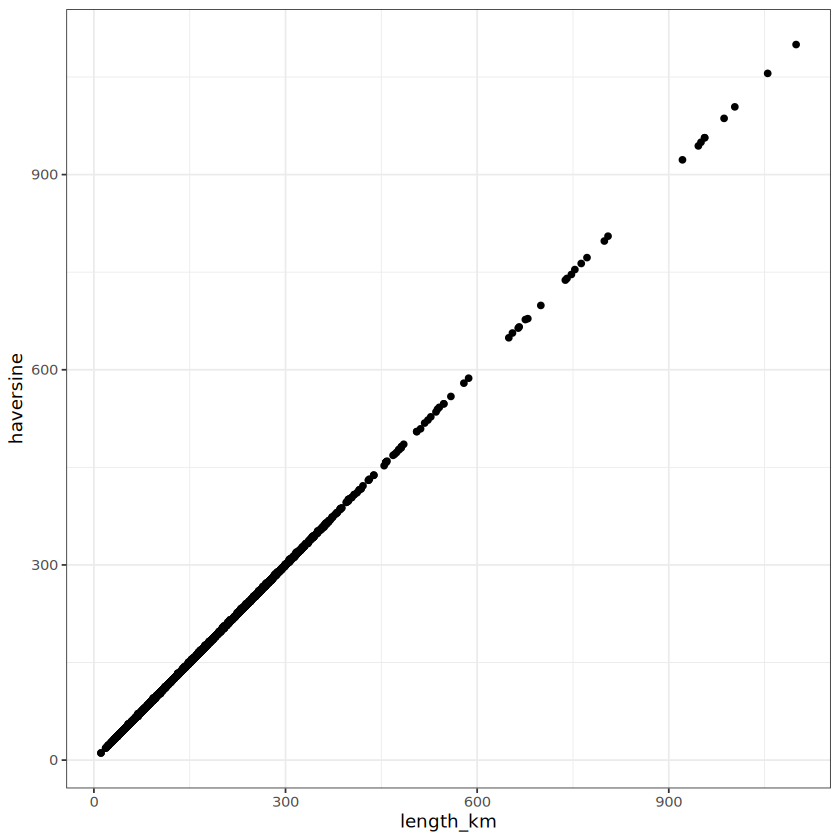

In [3]:
# we do not trust the length_km field: let us calculate the distances by ourselves
dat_edges$haversine <- 1e-3*geosphere::distHaversine( cbind(dat_nodes[dat_edges$from,]$lon,dat_nodes[dat_edges$from,]$lat), cbind(dat_nodes[dat_edges$to,]$lon,dat_nodes[dat_edges$to,]$lat) )

# if length_km was correct, then the two measures should correlate very well, and they do
ggplot(dat_edges, aes(length_km, haversine)) + theme_bw() + geom_point()

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


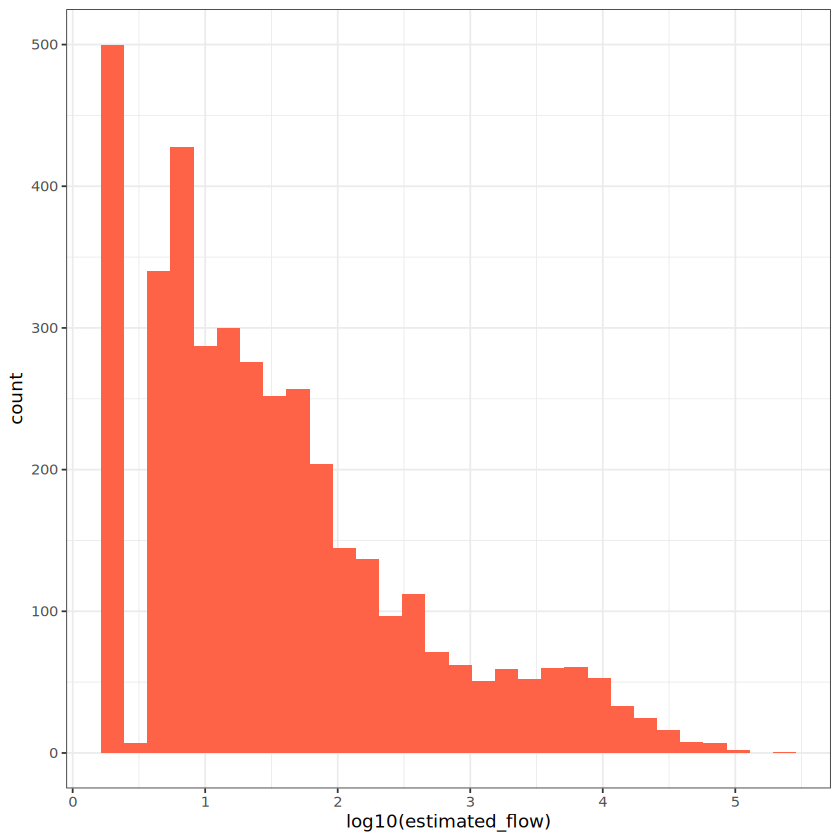

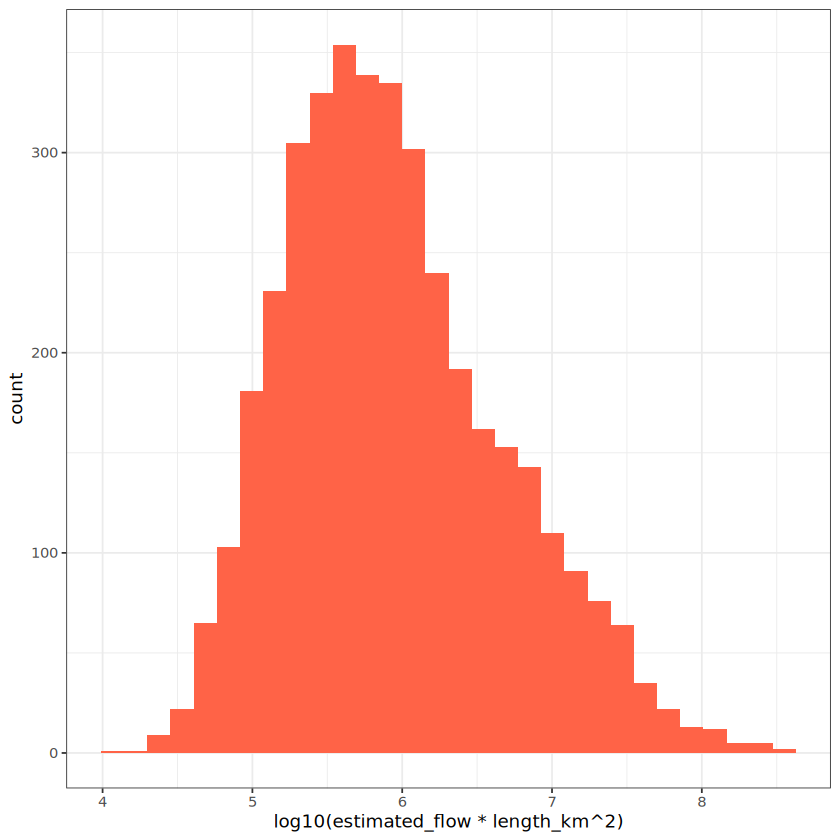

In [4]:
ggplot(dat_edges, aes(log10(estimated_flow))) + theme_bw() + geom_histogram(fill="tomato")
ggplot(dat_edges, aes(log10(estimated_flow*length_km^2))) + theme_bw() + geom_histogram(fill="tomato")

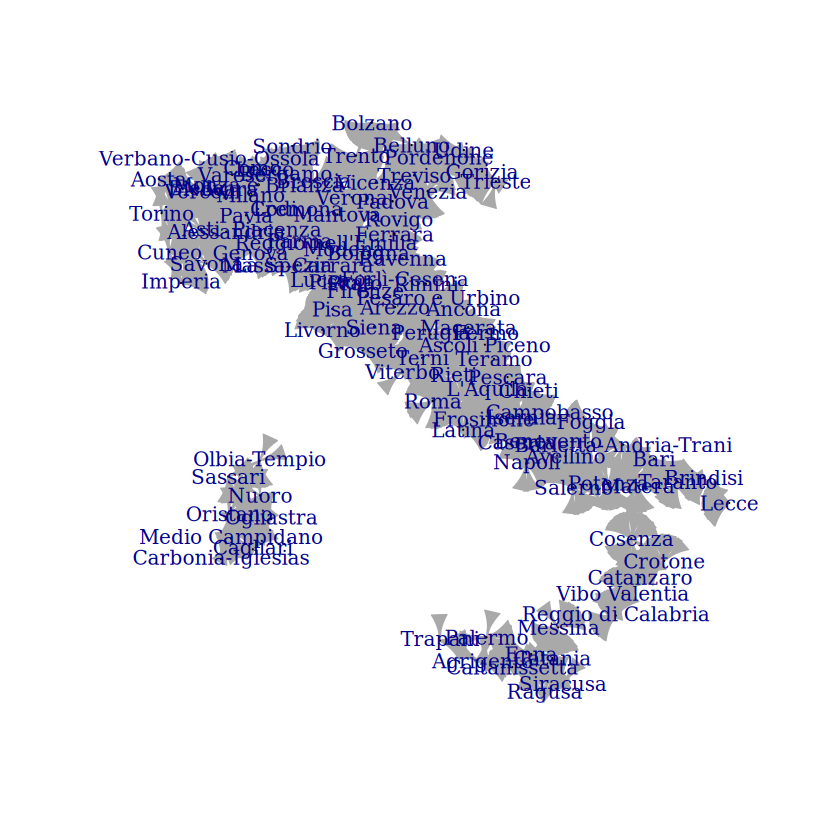

In [5]:
# Build the moblity network
g <- graph_from_data_frame(dat_edges[,c("from", "to")], directed=T, vertices=sort(dat_nodes$adm_id))
E(g)$weight <- dat_edges$estimated_flow
V(g)$pop <- dat_nodes$population
V(g)$label <- dat_nodes$adm_name


# Set the layout for plotting the network
layout <- matrix(NA, nrow(dat_nodes), 2)
layout[,1] <- dat_nodes$lon
layout[,2] <- dat_nodes$lat


# Visualize
sizes_nodes <- sqrt(strength(g, mode="all"))
sizes_edges <- E(g)$weight

plot(g, layout=layout, vertex.size=sizes_nodes/max(sizes_nodes), edge.width=sizes_edges/max(sizes_edges))

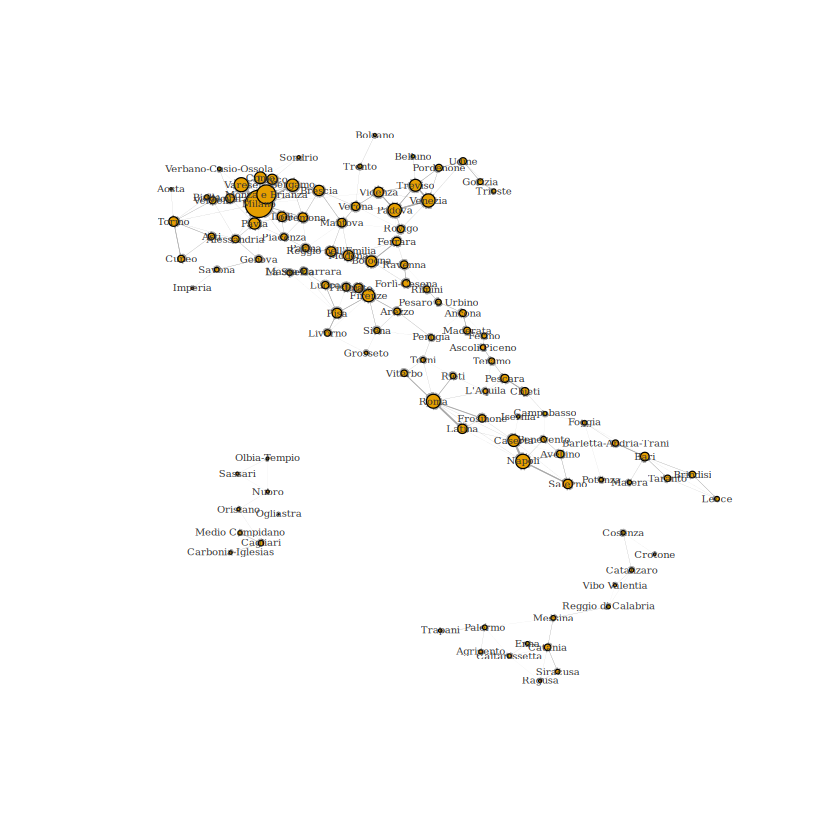

In [6]:
plot(g, layout=layout, vertex.label=V(g)$label, vertex.label.cex=.5, vertex.label.color="gray20", vertex.size=10*sizes_nodes/max(sizes_nodes), edge.arrow.size=0.05, edge.arrow.width=0.05, edge.width=5*sizes_edges/max(sizes_edges))

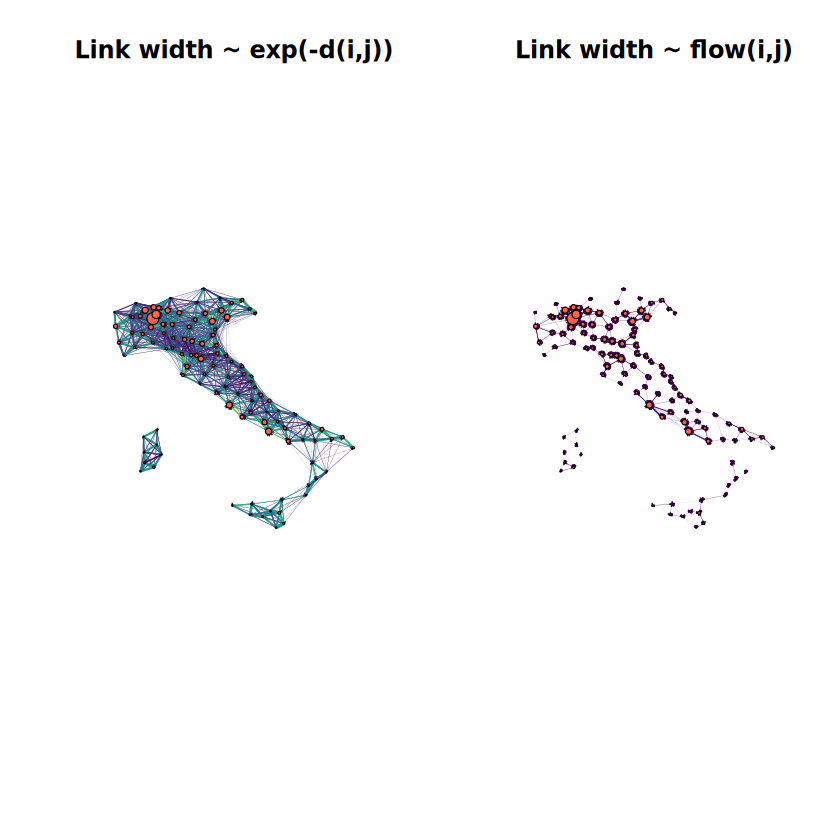

In [7]:
# let's use our distance for the visualization
mypal <- viridis::viridis_pal()(10)

par(mfrow=c(1,2))

w <- log10(E(g)$weight)
edge_colors <- vec2pal(w, mypal)
sizes_edges <- exp(-dat_edges$haversine/40)

plot(g, layout=layout, 
        vertex.label=NA, 
        vertex.label.cex=.5, 
        vertex.label.color="gray20", 
        vertex.color="tomato",
        vertex.size=10*sizes_nodes/max(sizes_nodes), 
        edge.arrow.size=0.05, 
        edge.arrow.width=0.05, 
        edge.width=5*sizes_edges/max(sizes_edges), 
        edge.color=edge_colors,
        main="Link width ~ exp(-d(i,j))")


w <- E(g)$weight
edge_colors <- vec2pal(w, mypal)
sizes_edges <- w

plot(g, layout=layout, 
        vertex.label=NA, 
        vertex.label.cex=.5, 
        vertex.label.color="gray20", 
        vertex.color="tomato",
        vertex.size=10*sizes_nodes/max(sizes_nodes), 
        edge.arrow.size=0.05, 
        edge.arrow.width=0.05, 
        edge.width=5*sizes_edges/max(sizes_edges), 
        edge.color=edge_colors,
        main="Link width ~ flow(i,j)")


## 1. Gravity Models
### Use population data to build exponential and power-law gravity models. Fit the parameters.

In [8]:
data_expgravity <- data.frame(
  Ni = dat_nodes$population[match(dat_edges$from, dat_nodes$adm_id)],
  Nj = dat_nodes$population[match(dat_edges$to, dat_nodes$adm_id)],
  d  = dat_edges$haversine,
  true_flow = dat_edges$estimated_flow,
  pred_flow = NA
)

print(head(data_expgravity))

# exponential gravity model
expgravity_func <- function(Ni, Nj, d, k, alpha, beta, d0) {
    return( k * Ni**alpha * Nj**beta / ( exp(d/d0) ) )
}

      Ni      Nj         d true_flow pred_flow
1 170911 2259523  73.64941   9238.94        NA
2 369018 2259523  98.85027   1491.56        NA
3 587098 2259523  75.27707  26007.20        NA
4 214638 2259523  65.88652  18231.92        NA
5 421284 2259523 102.58301   3974.58        NA
6 125666 2259523  65.30002   2071.72        NA



Formula: true_flow ~ expgravity_func(Ni, Nj, d, k, alpha, beta, d0)

Parameters:
       Estimate Std. Error t value Pr(>|t|)    
k     4.095e-06  1.064e-06   3.849 0.000121 ***
alpha 5.728e-01  1.151e-02  49.747  < 2e-16 ***
beta  1.186e+00  1.048e-02 113.180  < 2e-16 ***
d0    2.531e+01  2.707e-01  93.511  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2492 on 3899 degrees of freedom

Number of iterations to convergence: 25 
Achieved convergence tolerance: 5.888e-06


`geom_smooth()` using formula = 'y ~ x'


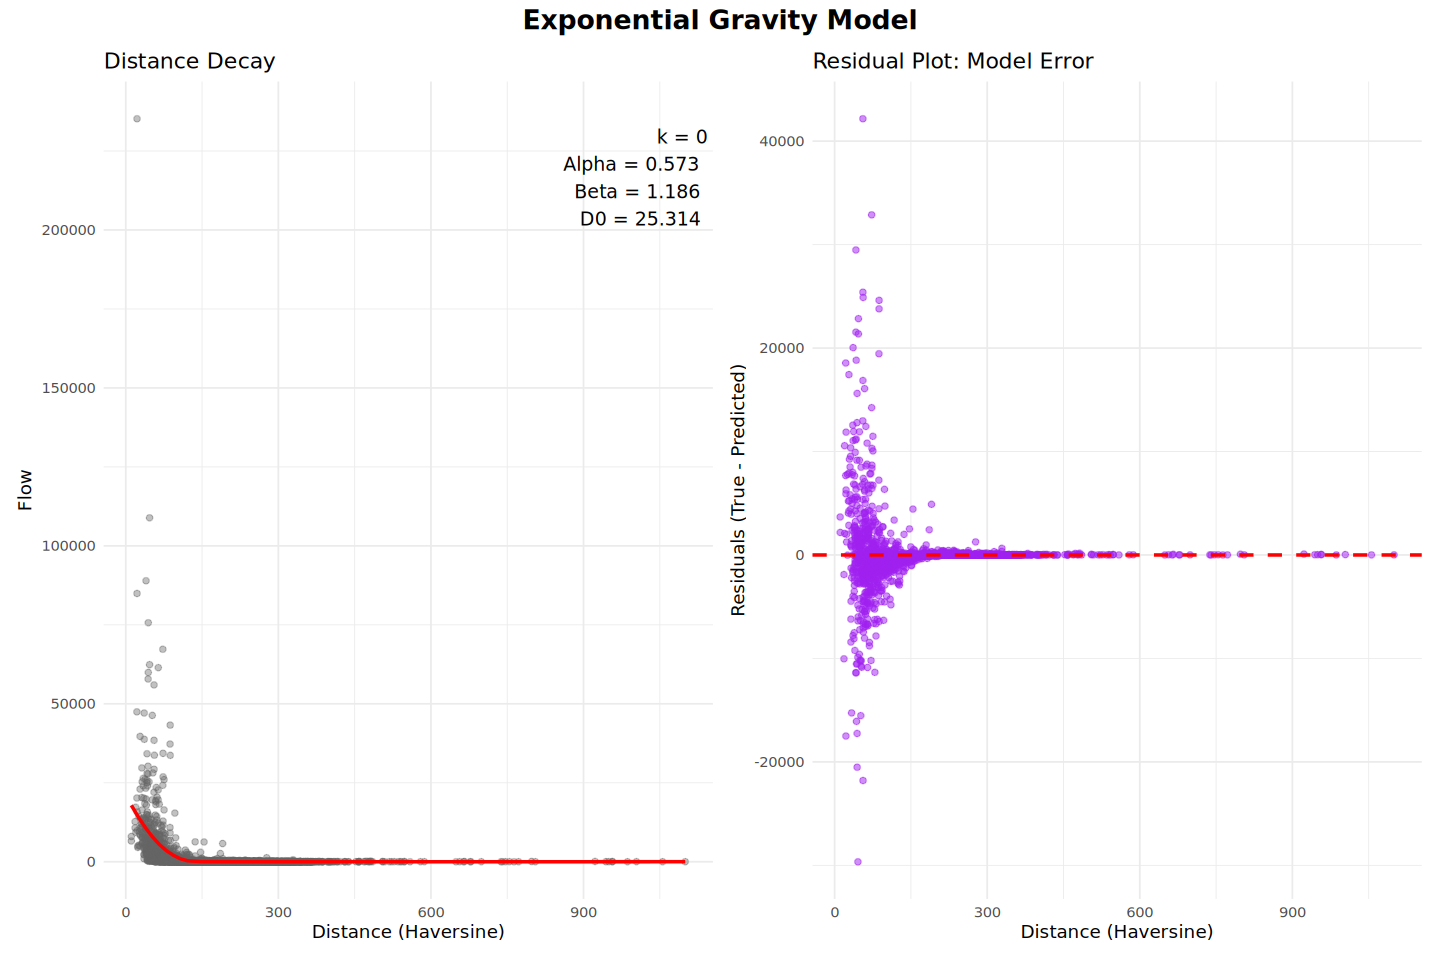

In [9]:
fit_expgravity <- nls(true_flow ~ expgravity_func(Ni, Nj, d, k, alpha, beta, d0),
                     data = data_expgravity,
                     start = list(k=1, alpha=1, beta=1, d0=mean(data_expgravity$d)))

summary(fit_expgravity)

expgravity_coeffs <- coef(fit_expgravity)
param_text <- paste0(
  "k = ", round(expgravity_coeffs["k"], 3), "\n",
  "Alpha = ", round(expgravity_coeffs["alpha"], 3), "\n",
  "Beta = ", round(expgravity_coeffs["beta"], 3), "\n",
  "D0 = ", round(expgravity_coeffs["d0"], 3)
)

data_expgravity$pred_flow <- predict(fit_expgravity)

# plot
data_expgravity$residual <- data_expgravity$true_flow - data_expgravity$pred_flow

p1 <- ggplot(data_expgravity, aes(x = d)) +
  geom_point(aes(y = true_flow), alpha = 0.4, color = "gray40") +
  geom_smooth(aes(y = pred_flow), method = "loess", color = "red", se = FALSE) +
  annotate(
    "text",
    label = param_text, 
    x = Inf, y = Inf,
    hjust = 1.1, vjust = 1.5,
    size = 4
  ) +
  labs(
    title = "Distance Decay",
    x = "Distance (Haversine)",
    y = "Flow"
  ) +
  theme_minimal()

p2 <- ggplot(data_expgravity, aes(x = d, y = residual)) +
  geom_point(alpha = 0.5, color = "purple") +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Residual Plot: Model Error",
    x = "Distance (Haversine)",
    y = "Residuals (True - Predicted)"
  ) +
  theme_minimal()

options(repr.plot.width = 12, repr.plot.height = 8)

combined_figure <- p1 | p2

combined_figure + plot_annotation(
  title = "Exponential Gravity Model",
  theme = theme(plot.title = element_text(size = 16, face = "bold", hjust = 0.5))
)

In [10]:
data_powgravity <- data.frame(
  Ni = dat_nodes$population[match(dat_edges$from, dat_nodes$adm_id)],
  Nj = dat_nodes$population[match(dat_edges$to, dat_nodes$adm_id)],
  d  = dat_edges$haversine,
  true_flow = dat_edges$estimated_flow,
  pred_flow = NA
)

powgravity_func <- function(Ni, Nj, d, k, alpha, beta, gamma) {
    return( k * Ni**alpha * Nj**beta / ( d**gamma ) )
}


Formula: true_flow ~ powgravity_func(Ni, Nj, d, k, alpha, beta, gamma)

Parameters:
       Estimate Std. Error t value Pr(>|t|)    
k     0.0033975  0.0009618   3.532 0.000417 ***
alpha 0.4957983  0.0125815  39.407  < 2e-16 ***
beta  1.1336374  0.0113293 100.063  < 2e-16 ***
gamma 1.8299504  0.0155141 117.954  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2814 on 3899 degrees of freedom

Number of iterations to convergence: 34 
Achieved convergence tolerance: 5.652e-06


`geom_smooth()` using formula = 'y ~ x'


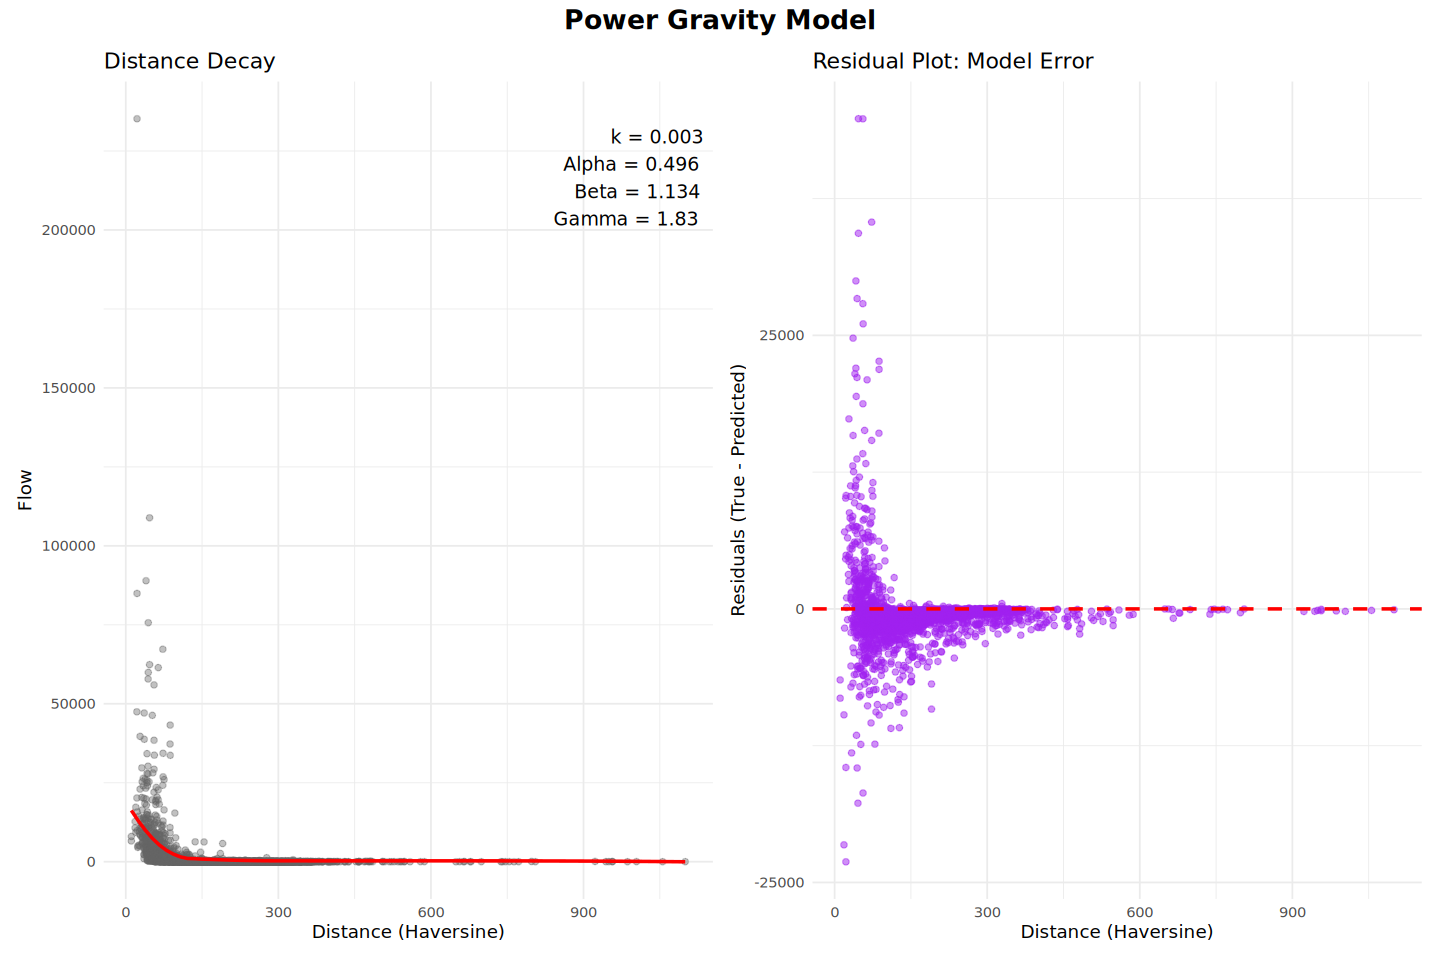

In [11]:
fit_powgravity <- nls(true_flow ~ powgravity_func(Ni, Nj, d, k, alpha, beta, gamma),
                     data = data_powgravity,
                     start = list(k=1, alpha=1, beta=1, gamma=1))

summary(fit_powgravity)
powgravity_coeffs <- coef(fit_powgravity)
param_text <- paste0(
  "k = ", round(powgravity_coeffs["k"], 3), "\n",
  "Alpha = ", round(powgravity_coeffs["alpha"], 3), "\n",
  "Beta = ", round(powgravity_coeffs["beta"], 3), "\n",
  "Gamma = ", round(powgravity_coeffs["gamma"], 3)
)

data_powgravity$pred_flow <- predict(fit_powgravity)

# plot
data_powgravity$residual <- data_powgravity$true_flow - data_powgravity$pred_flow

p1 <- ggplot(data_powgravity, aes(x = d)) +
  geom_point(aes(y = true_flow), alpha = 0.4, color = "gray40") +
  geom_smooth(aes(y = pred_flow), method = "loess", color = "red", se = FALSE) +
  annotate(
    "text",
    label = param_text, 
    x = Inf, y = Inf,
    hjust = 1.1, vjust = 1.5,
    size = 4
  ) +
  labs(
    title = "Distance Decay",
    x = "Distance (Haversine)",
    y = "Flow"
  ) +
  theme_minimal()

p2 <- ggplot(data_powgravity, aes(x = d, y = residual)) +
  geom_point(alpha = 0.5, color = "purple") +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Residual Plot: Model Error",
    x = "Distance (Haversine)",
    y = "Residuals (True - Predicted)"
  ) +
  theme_minimal()

options(repr.plot.width = 12, repr.plot.height = 8)

combined_figure <- p1 | p2

combined_figure + plot_annotation(
  title = "Power Gravity Model",
  theme = theme(plot.title = element_text(size = 16, face = "bold", hjust = 0.5))
)

## Radiation Model

In [17]:
data_radmodel <- data.frame(
  Ni = dat_nodes$population[match(dat_edges$from, dat_nodes$adm_id)],
  Nj = dat_nodes$population[match(dat_edges$to, dat_nodes$adm_id)],
  d  = dat_edges$haversine,
  true_flow = dat_edges$estimated_flow,
  pred_flow = NA
)

S_matrix <- matrix(0, nrow(dat_nodes), nrow(dat_nodes))
rownames(S_matrix) <- dat_nodes$adm_id
colnames(S_matrix) <- dat_nodes$adm_id

for (i in 1:nrow(dat_nodes)) {
    origin_id <- dat_nodes$adm_id[i]

    data <- data.frame(
        to = dat_nodes$adm_id,
        d = geosphere::distHaversine(
                c(dat_nodes$lon[i], dat_nodes$lat[i]), 
                cbind(dat_nodes$lon, dat_nodes$lat)
            ),
        Nj = dat_nodes$population
    )
    
    # remove the origin node so its population isn't included in Sij
    data <- data[data$to != origin_id, ]
    
    # sort by distance
    data <- data[order(data$d), ]
    
    # calculate cumulative sum, but subtract the current row's Nj
    data$Sij <- cumsum(data$Nj) - data$Nj
    
    # map back to matrix using character indices 
    S_matrix[as.character(origin_id), as.character(data$to)] <- data$Sij
}

In [ ]:
data_radmodel$Sij <- S_matrix[cbind(as.character(dat_edges$from), as.character(dat_edges$to))]

M_total <- sum(as.numeric(dat_nodes$population), na.rm = TRUE)

dat_edges$Ti <- ave(dat_edges$estimated_flow, dat_edges$from, FUN = sum)
data_radmodel$Ti <- dat_edges$Ti

data_radmodel$pred_flow <- with(data_radmodel, {
    
    # normalization factor
    norm_factor <- 1 / (1 - as.numeric(Ni) / M_total)
    
    rad_prob <- (as.numeric(Ni) * as.numeric(Nj)) / ((as.numeric(Ni) + Sij) * (as.numeric(Ni) + as.numeric(Nj) + Sij))
    
    Ti * norm_factor * rad_prob
})

print(head(data_radmodel))

      Ni      Nj         d true_flow pred_flow     Sij       Ti
1 170911 2259523  73.64941   9238.94  318.8694 5184339 33576.18
2 369018 2259523  98.85027   1491.56  552.2096 7994121 58476.18
3 587098 2259523  75.27707  26007.20 9657.5583  704542 33067.94
4 214638 2259523  65.88652  18231.92 4176.4074 1008382 36547.90
5 421284 2259523 102.58301   3974.58  417.8146 7821982 37735.84
6 125666 2259523  65.30002   2071.72  916.1879  175585  2483.96


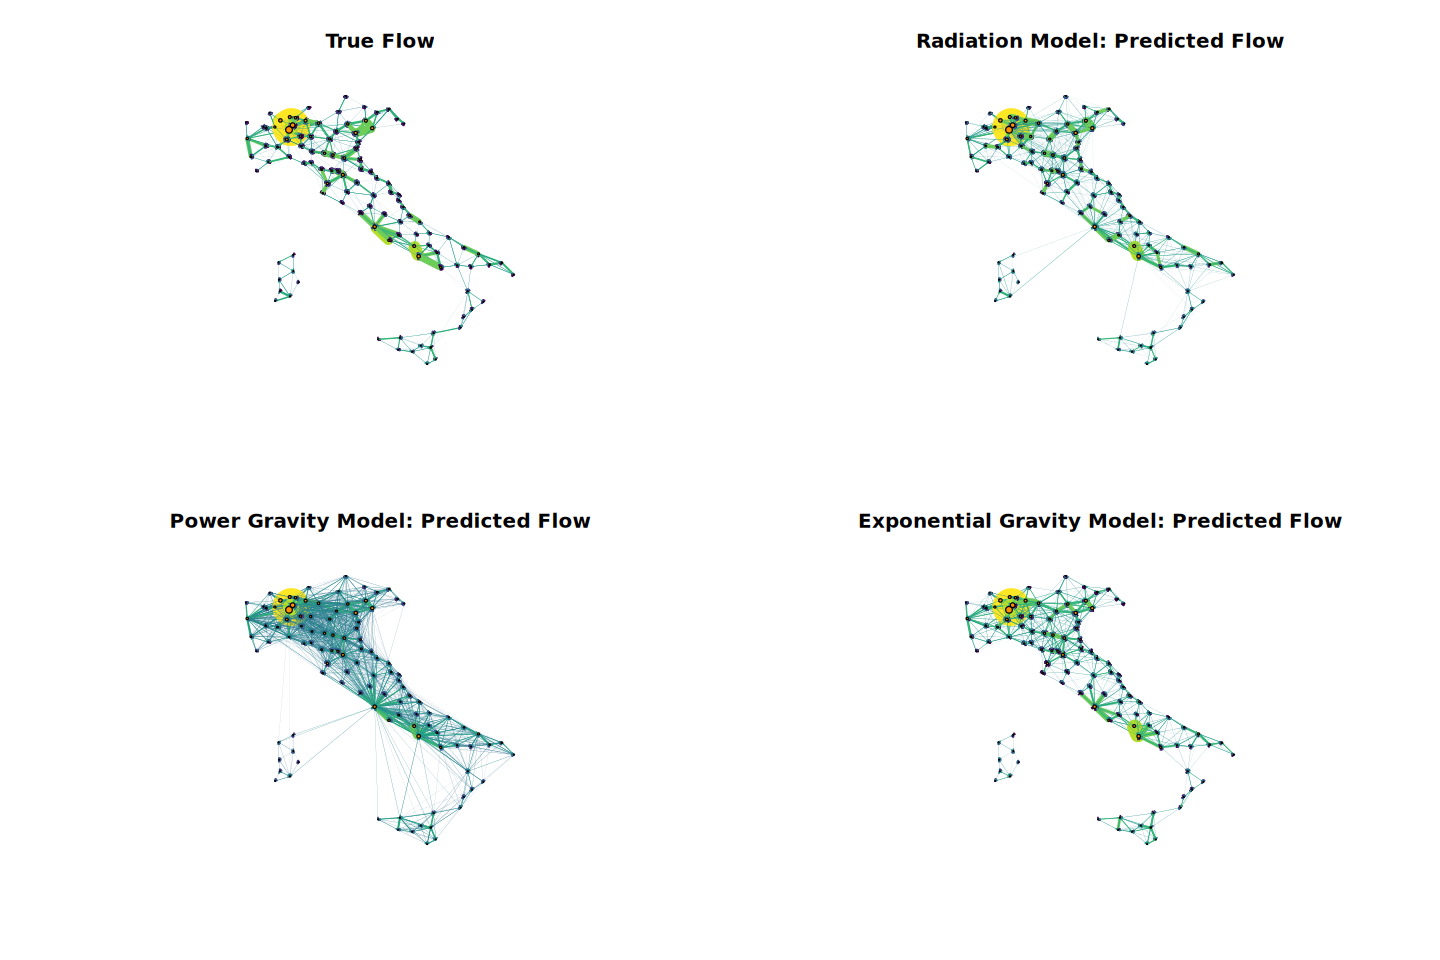

In [38]:
par(mfrow=c(2,2))
mypal <- viridis::viridis_pal()(10)

# ---------------------------------------------------------
# 1. True Flow
# ---------------------------------------------------------
sizes_edges <- E(g)$weight
w_true <- log10(sizes_edges)
edge_colors_true <- vec2pal(w_true, mypal)

plot(g, layout=layout, 
        vertex.label=NA, 
        vertex.label.cex=.5, 
        vertex.label.color="gray20",
        vertex.color="#ff9100",
        vertex.size=5*sizes_nodes/max(sizes_nodes), 
        edge.arrow.size=0.05, 
        edge.arrow.width=0.05, 
        edge.width=30*sizes_edges/max(sizes_edges), 
        edge.color=edge_colors_true,
        main="True Flow")

# ---------------------------------------------------------
# 2. Radiation Model
# ---------------------------------------------------------
sizes_edges_rad <- data_radmodel$pred_flow
# Added +1 to prevent log10(0) issues if any predicted flows are 0
w_rad <- log10(sizes_edges_rad + 1) 
edge_colors_rad <- vec2pal(w_rad, mypal)

plot(g, layout=layout, 
        vertex.label=NA, 
        vertex.label.cex=.5, 
        vertex.label.color="gray20", 
        vertex.color="#ff9100",
        vertex.size=5*sizes_nodes/max(sizes_nodes), 
        edge.arrow.size=0.05, 
        edge.arrow.width=0.05, 
        edge.width=30*sizes_edges_rad/max(sizes_edges_rad), 
        edge.color=edge_colors_rad,
        main="Radiation Model: Predicted Flow")

# ---------------------------------------------------------
# 3. Power Gravity Model
# ---------------------------------------------------------
sizes_edges_gravity <- data_powgravity$pred_flow
w_grav <- log10(sizes_edges_gravity + 1)
edge_colors_grav <- vec2pal(w_grav, mypal)

plot(g, layout=layout, 
        vertex.label=NA, 
        vertex.label.cex=.5, 
        vertex.label.color="gray20",
        vertex.color="#ff9100",
        vertex.size=5*sizes_nodes/max(sizes_nodes), 
        edge.arrow.size=0.05, 
        edge.arrow.width=0.05, 
        edge.width=30*sizes_edges_gravity/max(sizes_edges_gravity), 
        edge.color=edge_colors_grav,
        main="Power Gravity Model: Predicted Flow")

# ---------------------------------------------------------
# 4. Exponential Gravity Model
# ---------------------------------------------------------
sizes_edges_expgravity <- data_expgravity$pred_flow
w_expgrav <- log10(sizes_edges_expgravity + 1)
edge_colors_expgrav <- vec2pal(w_expgrav, mypal)

plot(g, layout=layout, 
        vertex.label=NA, 
        vertex.label.cex=.5, 
        vertex.label.color="gray20",
        vertex.color="#ff9100",
        vertex.size=5*sizes_nodes/max(sizes_nodes), 
        edge.arrow.size=0.05, 
        edge.arrow.width=0.05, 
        edge.width=30*sizes_edges_expgravity/max(sizes_edges_expgravity), 
        edge.color=edge_colors_expgrav,
        main="Exponential Gravity Model: Predicted Flow")